<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/main/brfss_experiment_1_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 1 - CDC BRFSS

Baseline comparison using the raw, imbalanced CDC BRFSS dataset.

Models:
- Logistic Regression
- LightGBM
- XGBoost

Metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- AUC-ROC


In [12]:
# 1 imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

from IPython.display import display

print("imports successfully loaded")

imports successfully loaded


In [13]:
# 2 clone repo / move into project folder
if not os.path.exists("/content/Predicting-Type-2-Diabetes"):
    !git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git

%cd /content/Predicting-Type-2-Diabetes

/content/Predicting-Type-2-Diabetes


In [14]:
# 3 load CDC BRFSS data and create train/test split
path = "data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(path)

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scale only for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("-" * 50)
print(" Experiment 1: CDC Raw Imbalanced Data Loaded")
print("-" * 50)
print(f"Dataset shape: {df.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("\nTarget balance (%):")
print((y.value_counts(normalize=True) * 100).round(2))

--------------------------------------------------
 Experiment 1: CDC Raw Imbalanced Data Loaded
--------------------------------------------------
Dataset shape: (253680, 22)
X_train shape: (202944, 21)
X_test shape: (50736, 21)

Target balance (%):
Diabetes_binary
0.0    86.07
1.0    13.93
Name: proportion, dtype: float64


In [15]:
# 4 model training
print("-" * 50)
print(" Training Models — Experiment 1 (CDC Raw Baseline)")
print("-" * 50)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("  Logistic Regression    — done")

# LightGBM
lgbm = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm.fit(X_train, y_train)
print("  LightGBM               — done")

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
print("  XGBoost                — done")

print("\nAll baseline models trained successfully.")

--------------------------------------------------
 Training Models — Experiment 1 (CDC Raw Baseline)
--------------------------------------------------
  Logistic Regression    — done
  LightGBM               — done
  XGBoost                — done

All baseline models trained successfully.


In [16]:
# 5 summary metric table
model_inputs = {
    "Logistic Regression": {
        "model": lr,
        "X_test": X_test_scaled
    },
    "LightGBM": {
        "model": lgbm,
        "X_test": X_test
    },
    "XGBoost": {
        "model": xgb_model,
        "X_test": X_test
    }
}

results = []

for name, item in model_inputs.items():
    model = item["model"]
    X_eval = item["X_test"]

    y_pred = model.predict(X_eval)
    y_pred_prob = model.predict_proba(X_eval)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_pred_prob)
    })

results_df = pd.DataFrame(results)

print("-" * 60)
print(" Experiment 1 - CDC Baseline Model Comparison (Raw Data)")
print("-" * 60)

display(results_df.round(4))

------------------------------------------------------------
 Experiment 1 - CDC Baseline Model Comparison (Raw Data)
------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,0.8621,0.5171,0.1583,0.2424,0.8192
1,LightGBM,0.8655,0.5591,0.1640,0.2536,0.8269
2,XGBoost,0.8634,0.5309,0.1665,0.2535,0.8237


In [17]:
# 6 predictions and probabilities
model_preds = {}

for name, item in model_inputs.items():
    model = item["model"]
    X_eval = item["X_test"]

    # hard predictions for Accuracy, Precision, Recall, and F1
    y_pred = model.predict(X_eval)

    # probability predictions for AUC-ROC and ROC curves
    y_prob = model.predict_proba(X_eval)[:, 1]

    model_preds[name] = {"y_pred": y_pred, "y_prob": y_prob}

print("Predictions and probabilities generated for all CDC baseline models.")

Predictions and probabilities generated for all CDC baseline models.


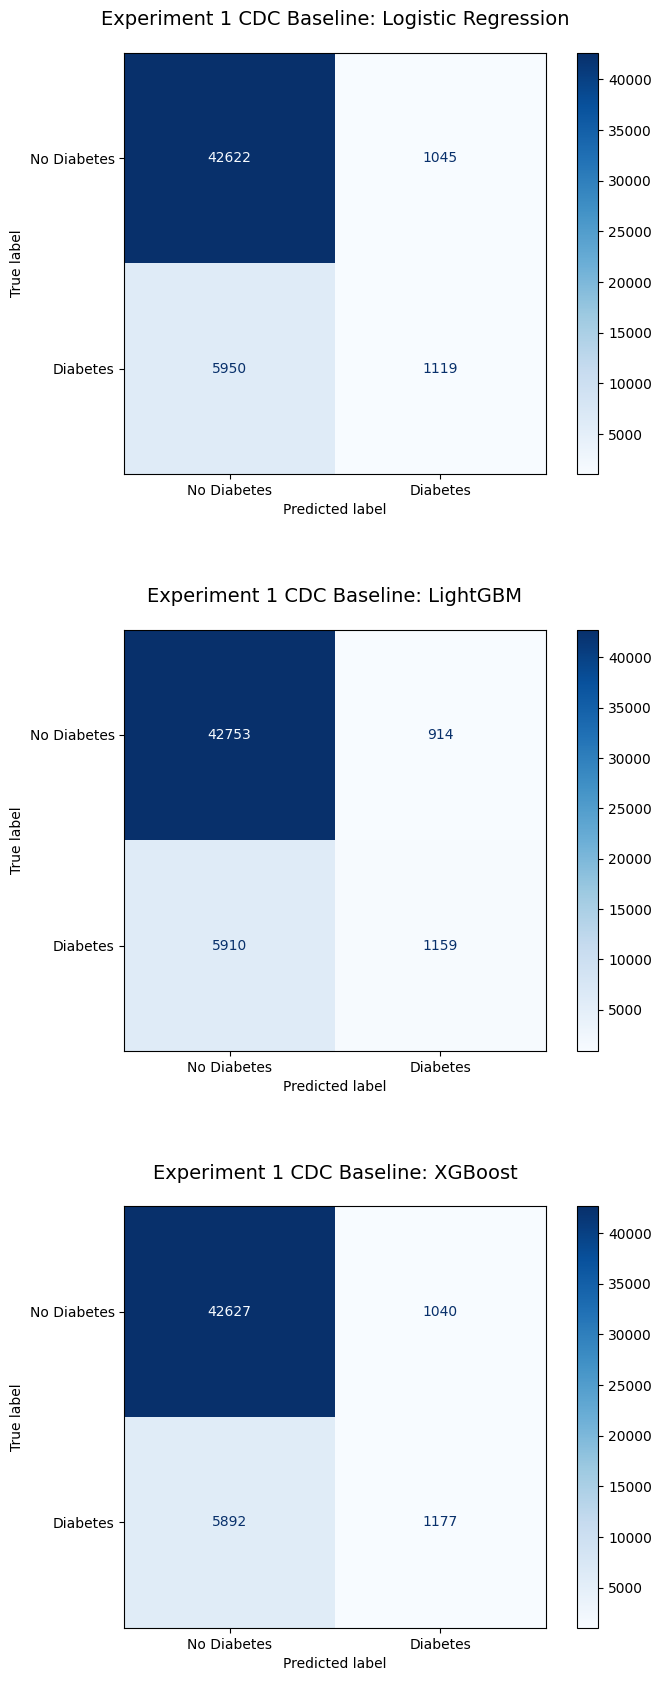

In [18]:
# 7 confusion matrix grid
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

for i, (name, preds) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Diabetes", "Diabetes"]
    )

    disp.plot(ax=axes[i], cmap="Blues", colorbar=True)
    axes[i].set_title(f"Experiment 1 CDC Baseline: {name}", fontsize=14, pad=20)

plt.tight_layout(pad=5.0)
plt.show()

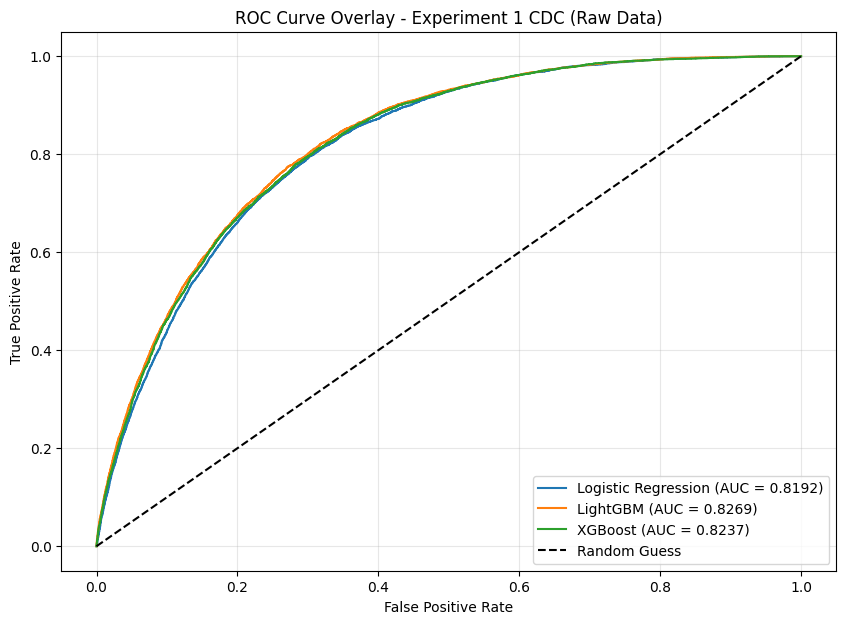

In [19]:
# 8 ROC curve
plt.figure(figsize=(10, 7))

for name, preds in model_preds.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Overlay - Experiment 1 CDC (Raw Data)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

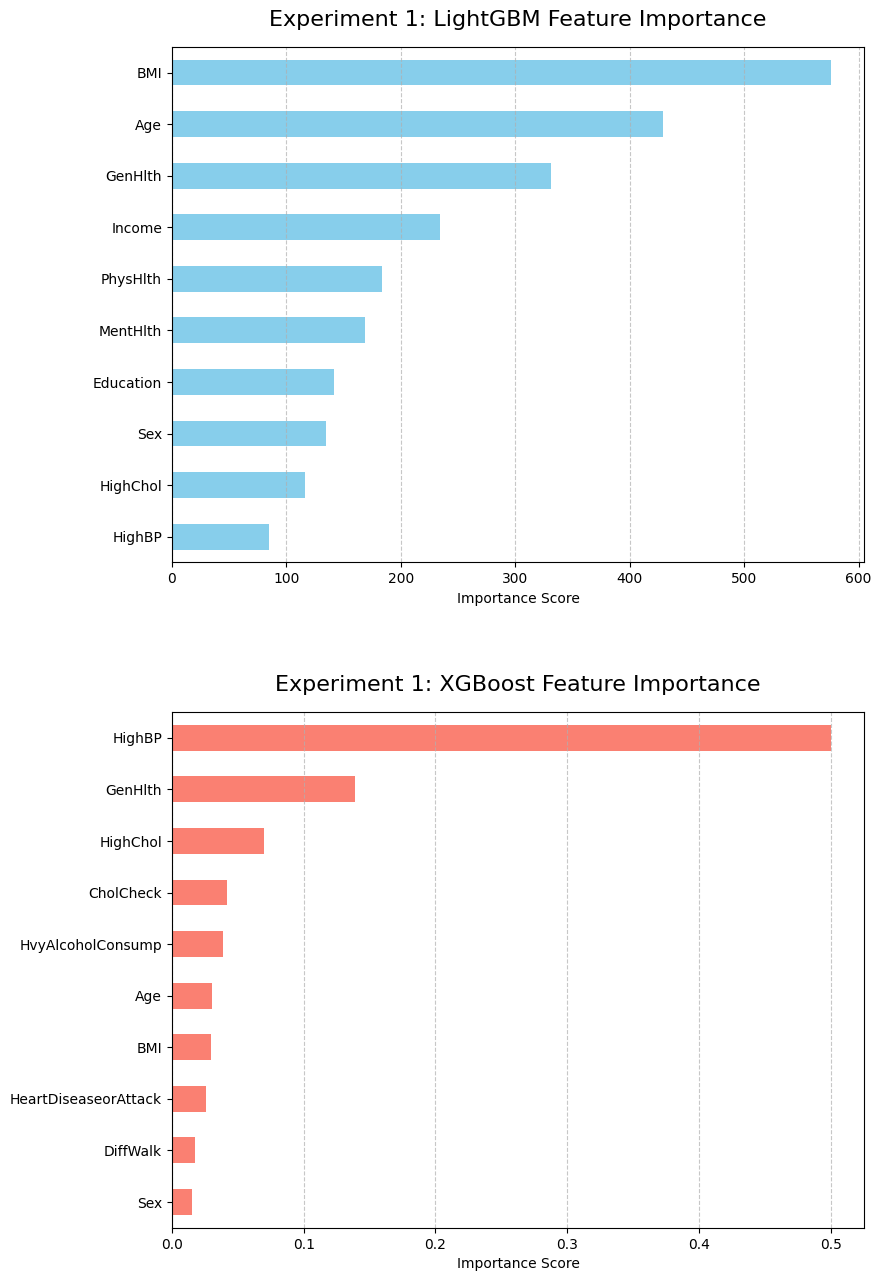

In [20]:
# 9 feature importance for tree-based models

fig, axes = plt.subplots(2, 1, figsize=(10, 14))

# LightGBM feature importance
lgbm_importances = pd.Series(
    lgbm.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

lgbm_importances.tail(10).plot(kind="barh", ax=axes[0], color="skyblue")
axes[0].set_title("Experiment 1: LightGBM Feature Importance", fontsize=16, pad=15)
axes[0].set_xlabel("Importance Score")
axes[0].grid(axis="x", linestyle="--", alpha=0.7)

# XGBoost feature importance
xgb_importances = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

xgb_importances.tail(10).plot(kind="barh", ax=axes[1], color="salmon")
axes[1].set_title("Experiment 1: XGBoost Feature Importance", fontsize=16, pad=15)
axes[1].set_xlabel("Importance Score")
axes[1].grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout(pad=5.0)
plt.show()

In [21]:
# 10 short finding
best_f1 = results_df.sort_values("F1 Score", ascending=False).iloc[0]
best_auc = results_df.sort_values("AUC-ROC", ascending=False).iloc[0]

print("Short Experiment 1 Finding")
print("-" * 35)
print(f"Best model by F1 Score: {best_f1['Model']} ({best_f1['F1 Score']:.4f})")
print(f"Best model by AUC-ROC : {best_auc['Model']} ({best_auc['AUC-ROC']:.4f})")
print("\nNote: This is the raw, imbalanced baseline. Experiment 2 will compare whether SMOTE improves recall.")

Short Experiment 1 Finding
-----------------------------------
Best model by F1 Score: LightGBM (0.2536)
Best model by AUC-ROC : LightGBM (0.8269)

Note: This is the raw, imbalanced baseline. Experiment 2 will compare whether SMOTE improves recall.
